In [3]:
# ============================
# Import Required Libraries
# ============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [5]:
# ============================
# Load Dataset
# ============================

df = pd.read_csv("/workspaces/Heart-Disease-Prediction/heart_disease_health_indicators_BRFSS2015.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [6]:
print(df.head()) # First 5 rows
print("\nRows and Columns:", df.shape) # Shape of dataset
print('\nDataset information')
print(df.info())
print('\nStatistical summary')
print(df.describe())
print('\nCheck missing values')
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum()) # Check duplicate rows

   HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                   0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                   0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                   0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                   0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                   0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   Diabetes  PhysActivity  Fruits  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0       0.0           0.0     0.0  ...            1.0          0.0      5.0   
1       0.0           1.0     0.0  ...            0.0          1.0      3.0   
2       0.0           0.0     1.0  ...            1.0          1.0      5.0   
3       0.0           1.0     1.0  ...            1.0          0.0      2.0   
4       0.0           1.0     1.0  ...            1.0          0.0      2.0   

   MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  I

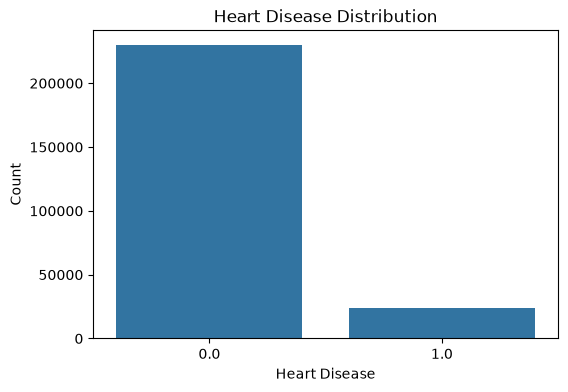

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='HeartDiseaseorAttack', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

In this graph, the x-axis shows the HeartDiseaseorAttack target:
0 means the person did not report heart disease or a heart attack.
1 means the person did report heart disease or a heart attack.

##### Correlation matrix
A correlation matrix is a table showing correlation coefficients between variables. It helps identify relationships and patterns in datasets. 

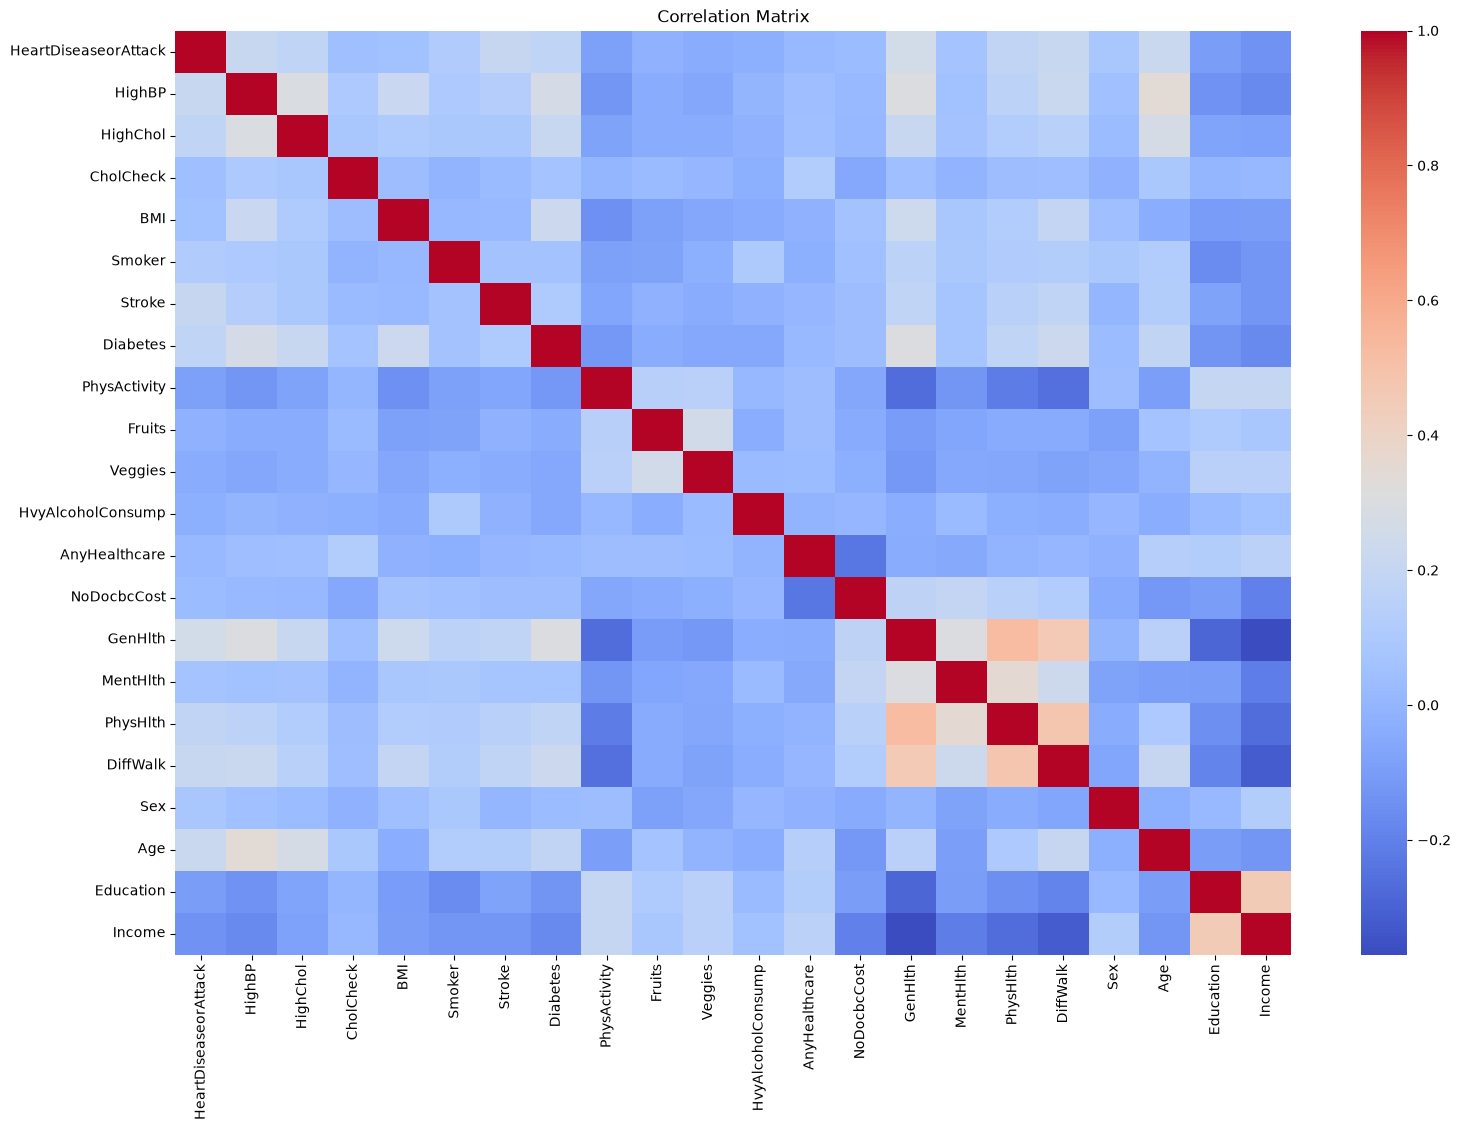

In [8]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [9]:
X = df.drop("HeartDiseaseorAttack", axis=1)

y = df["HeartDiseaseorAttack"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (202944, 21)
Testing Samples : (50736, 21)


##### Scaling
StandardScaler standardizes each feature so it has approximately mean: 0 and standard deviation: 1.
Scaling is important for models such as Logistic Regression and KNN because they are sensitive to feature magnitudes. For example, a feature ranging from 0 to 100 could otherwise dominate one ranging from 0 to 1. Decision Trees and Random Forests generally do not require scaling.


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")
# This saves the fitted scaler so new prediction data can be transformed consistently before being 
# passed to the model.

['scaler.pkl']

In [12]:
results = []

def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = "N/A"

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    mcc = matthews_corrcoef(y_test, y_pred)

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy)
    print("AUC :", auc)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("MCC :", mcc)

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(cm).plot()

    plt.title(name)

    plt.show()

    results.append([
        name,
        accuracy,
        auc,
        precision,
        recall,
        f1,
        mcc
    ])

##### Logistic regression 
It is a supervised classification machine learning algorithm. Unlike linear regression, which predicts continuous values, logistic regression predicts the probability of an input belonging to a specific class.

Logistic Regression
Accuracy : 0.9070679596341849
AUC : 0.8468397246235385
Precision : 0.5281195079086116
Recall : 0.1257585268884704
F1 Score : 0.2031434848740916
MCC : 0.22502285560803548

Classification Report

              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     45957
         1.0       0.53      0.13      0.20      4779

    accuracy                           0.91     50736
   macro avg       0.72      0.56      0.58     50736
weighted avg       0.88      0.91      0.88     50736



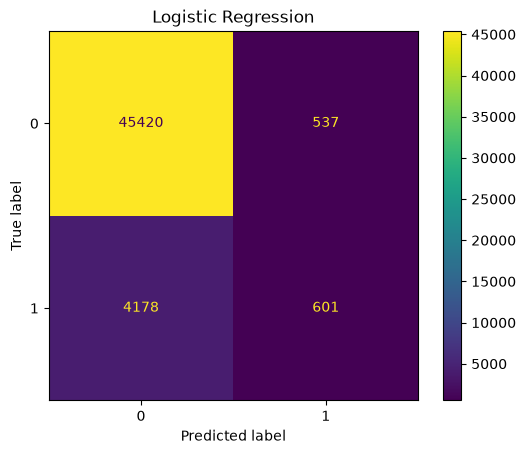

['logistic_regression.pkl']

In [13]:
# ============================
# Logistic Regression
# ============================

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test_scaled,
    y_test
)

joblib.dump(logistic_model, "logistic_regression.pkl")

##### Decision tree 
It is a supervised learning algorithm used for classification and regression tasks. It represents decisions in a hierarchical tree structure with a root node, internal nodes, branches, and leaf nodes. Internal nodes test attributes, branches represent outcomes of those tests, and leaf nodes provide the final prediction.

Decision Tree
Accuracy : 0.9068511510564491
AUC : 0.8364638992234991
Precision : 0.5369595536959554
Recall : 0.08056078677547604
F1 Score : 0.1401018922852984
MCC : 0.18148397937940455

Classification Report

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     45957
         1.0       0.54      0.08      0.14      4779

    accuracy                           0.91     50736
   macro avg       0.72      0.54      0.55     50736
weighted avg       0.88      0.91      0.87     50736



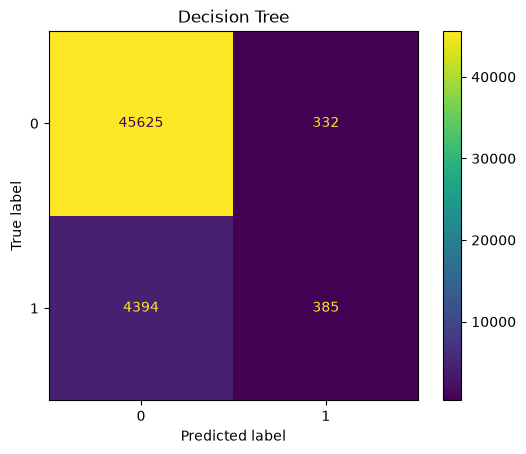

['decision_tree.pkl']

In [14]:
# ============================
# Decision Tree classifier
# ============================

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

decision_tree.fit(X_train, y_train)

evaluate_model(
    "Decision Tree",
    decision_tree,
    X_test,
    y_test
)

joblib.dump(decision_tree, "decision_tree.pkl")

##### KNN (K Nearest Neighbours)
Compute the distance from the query point to all training points. Select the k closest points.
For classification: choose the majority class among neighbors.
For regression: compute the average value of neighbors. 

KNN
Accuracy : 0.896207820876695
AUC : 0.7223485696662969
Precision : 0.37570188871873406
Recall : 0.15400711445909185
F1 Score : 0.2184624517661027
MCC : 0.19314031400613482

Classification Report

              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     45957
         1.0       0.38      0.15      0.22      4779

    accuracy                           0.90     50736
   macro avg       0.65      0.56      0.58     50736
weighted avg       0.87      0.90      0.88     50736



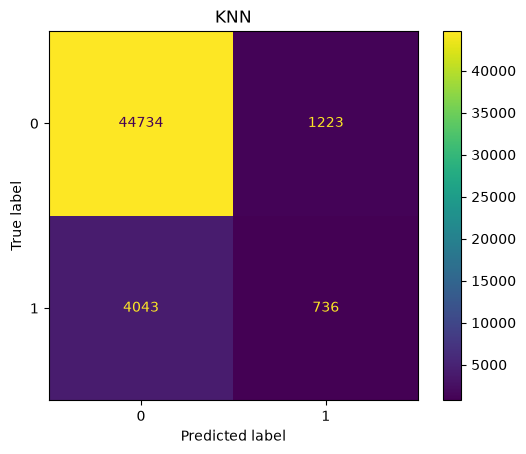

['knn.pkl']

In [15]:
# ============================
# KNN
# ============================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

evaluate_model(
    "KNN",
    knn_model,
    X_test_scaled,
    y_test
)

joblib.dump(knn_model, "knn.pkl")

##### Gaussian Naive Bayes
It is a classification algorithm that assumes the features follow a Gaussian (normal) distribution. Gaussian Naive Bayes is specifically designed for continuous numerical features. Each feature is modeled as a Gaussian distribution within each class.

Gaussian Naive Bayes
Accuracy : 0.8152593818984547
AUC : 0.8059831810627966
Precision : 0.2641199424933251
Recall : 0.5381879054195439
F1 Score : 0.35434318385341323
MCC : 0.2835218017861528

Classification Report

              precision    recall  f1-score   support

         0.0       0.95      0.84      0.89     45957
         1.0       0.26      0.54      0.35      4779

    accuracy                           0.82     50736
   macro avg       0.61      0.69      0.62     50736
weighted avg       0.88      0.82      0.84     50736



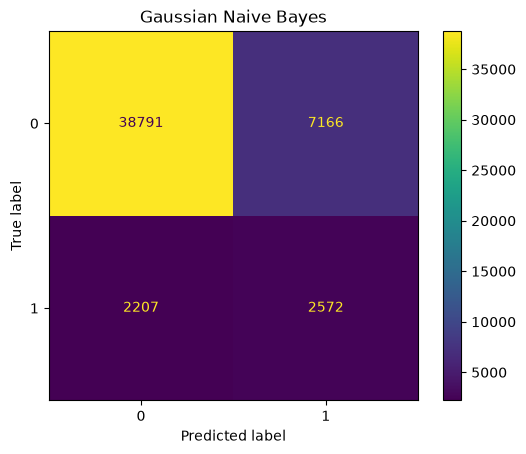

['naive_bayes.pkl']

In [16]:
# ============================
# Gaussian Naive Bayes
# ============================

naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

evaluate_model(
    "Gaussian Naive Bayes",
    naive_bayes,
    X_test,
    y_test
)

joblib.dump(naive_bayes, "naive_bayes.pkl")

##### Random Forest
It is a machine learning algorithm that builds multiple decision trees and combines their outputs to make predictions. The "randomness" in Random Forest comes from two key aspects: random sampling of data and random selection of features during the training process. 

Random Forest
Accuracy : 0.9016083254493851
AUC : 0.8171346753658837
Precision : 0.4137651821862348
Recall : 0.10692613517472274
F1 Score : 0.16993681410043232
MCC : 0.17280913375818074

Classification Report

              precision    recall  f1-score   support

         0.0       0.91      0.98      0.95     45957
         1.0       0.41      0.11      0.17      4779

    accuracy                           0.90     50736
   macro avg       0.66      0.55      0.56     50736
weighted avg       0.87      0.90      0.87     50736



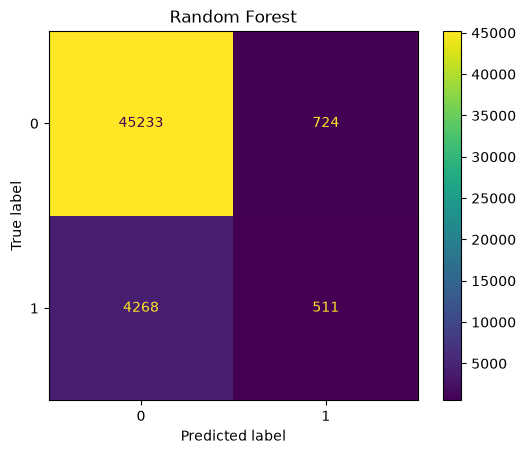

['random_forest.pkl']

In [17]:
# ============================
# Random Forest
# ============================

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

evaluate_model(
    "Random Forest",
    random_forest,
    X_test,
    y_test
)

joblib.dump(random_forest, "random_forest.pkl")

##### Note
The scaler is applied only to Logistic Regression and KNN because:
Logistic Regression can be affected by feature ranges, especially during optimization and regularization.
KNN uses distances between data points, so features with larger numeric ranges could dominate those distances.

The Decision Tree and Random Forest use threshold-based splits, which generally don’t need standardized features. Gaussian Naive Bayes models each feature’s distribution, so this workflow trains and uses it without scaling.

In [18]:
# ============================
# Model Comparison
# ============================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.907068,0.846840,0.528120,0.125759,0.203143,0.225023
1,Decision Tree,0.906851,0.836464,0.536960,0.080561,0.140102,0.181484
2,Random Forest,0.901608,0.817135,0.413765,0.106926,0.169937,0.172809
3,KNN,0.896208,0.722349,0.375702,0.154007,0.218462,0.193140
4,Gaussian Naive Bayes,0.815259,0.805983,0.264120,0.538188,0.354343,0.283522


In [19]:
# Save comparison table

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Comparison table saved.")

Comparison table saved.


In [20]:
best_model = results_df.iloc[0]["Model"]

print("Best Performing Model:")

print(best_model)

Best Performing Model:
Logistic Regression


In [21]:
# Select 200 random rows

test_data = df.sample(

    n=200,

    random_state=42

)

test_data.to_csv(

    "test_data.csv",

    index=False

)

print("test_data.csv generated successfully!")

test_data.csv generated successfully!


In [22]:
import pandas as pd

df = pd.read_csv("test_data.csv")

prediction_df = df.drop(columns=["HeartDiseaseorAttack"])

prediction_df.to_csv("prediction_data.csv", index=False)

In [23]:
import os

files = [

    "logistic_regression.pkl",

    "decision_tree.pkl",

    "knn.pkl",

    "naive_bayes.pkl",

    "random_forest.pkl",

    "scaler.pkl"

]

print("Saved Files\n")

for file in files:

    if os.path.exists(file):

        print(f"✔ {file}")

    else:

        print(f"✘ {file}")

Saved Files

✔ logistic_regression.pkl
✔ decision_tree.pkl
✔ knn.pkl
✔ naive_bayes.pkl
✔ random_forest.pkl
✔ scaler.pkl
